# PC Lab 5: Cross-Validation and Nested Cross-Validation

At the end of lab 2 we chose $k$ by looking at the test error, and flagged that as a shortcut:
once the test set has influenced a decision, it no longer measures performance on new data.
In this lab you do it properly.

Building a model involves two different questions, and they need different data:

- **Model selection**: which hyperparameter (or which method) should I use? This is answered with
  a **validation** set (also called a *tuning* set).
- **Model assessment**: how well will the chosen model do on new data? This is answered with a
  **test** set that played no role in any decision.

Mixing the two up is one of the most common mistakes in applied machine learning, and it always
errs in the same direction: the model looks better than it is. In the life sciences, where
datasets are often small because every labeled example costs an experiment, the effect can be
large.

### What you will be able to do after this lab

1. Implement $K$-fold cross-validation and use it to choose a hyperparameter.
2. Explain why the best cross-validated score is an optimistic estimate of performance.
3. Use nested cross-validation to estimate performance honestly and to compare two models.

In [1]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/BioML-UGent/MLLS/main/05_evaluation/promoters.csv", "promoters.csv")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

RANDOM_STATE = 42

## 1. The data: a small promoter library

A **promoter** is the stretch of DNA upstream of a gene where RNA polymerase binds to start
transcription. In *E. coli*, promoters share two short conserved motifs, roughly 35 and 10
nucleotides before the transcription start site (the "−35" and "−10" boxes, the latter also
known as the Pribnow box, consensus `TATAAT`). The motifs are not identical across promoters,
which is why recognizing a promoter from sequence alone is a classic machine learning problem.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/f/fd/Gene_structure_prokaryote_2_annotated.svg/1280px-Gene_structure_prokaryote_2_annotated.svg.png" width=600>

`promoters.csv` is derived from the
[UCI *E. coli* promoter dataset](https://archive.ics.uci.edu/dataset/67/molecular+biology+promoter+gene+sequences):
106 DNA sequences of 27 nucleotides, some of them promoters. The file has no header row. Its
columns are the label (`True` for a promoter), a name, and the sequence.

<div class="alert alert-success">

<b>EXERCISE 1.1</b>: <b>Load <code>promoters.csv</code> with column names <code>'promoter'</code>,
<code>'name'</code> and <code>'sequence'</code>, and count the sequences of each class. What
accuracy does a model reach that always predicts the most common class?</b>
</div>

In [2]:
df = pd.read_csv("promoters.csv", header=None, names=['promoter', 'name', 'sequence'])
print(df.head())
print(df['promoter'].value_counts())
# 53 vs 53: always predicting one class gives 50% accuracy, the baseline to beat

   promoter       name                     sequence
0      True        S10  agtatgtataatgcgcgggcttgtcgt
1      True       AMPC  tgtcgttacaatctaacgcatcgccaa
2      True       AROH  ttttgttatcatgctaaccacccggcg
3      True      DEOP2  agtagatgttagaatactaacaaactc
4      True  LEU1_TRNA  aaccactagaatgcgcctccgtggtag
promoter
True     53
False    53
Name: count, dtype: int64


Each position is a nominal feature with four values, so, as for the abalone's `sex` in lab 2, we
dummy-encode it: position 0 becomes the four binary features `0_a`, `0_c`, `0_g`, `0_t`, and so
on, giving 27 positions × 4 nucleotides = 108 features.

Note the shape of the result: **more features than instances**. That makes it easy for a model
to find patterns that are there by chance, and it makes every performance estimate noisy. Both
will matter in this lab.

In [3]:
X = pd.get_dummies(pd.DataFrame([list(s) for s in df['sequence']])).values.astype(float)
y = df['promoter'].astype(int).values      # 1 = promoter, 0 = not
print("X:", X.shape, "  y:", y.shape)

X: (106, 108)   y: (106,)


## 2. Cross-validation

To choose $k$ we need data the model was not fitted on, and that cannot be the test set. The
simplest option is to split off a single validation set, say 25% of the data. But with 106
sequences that is only 27 sequences, so one misclassification moves the accuracy by almost 4
percentage points, and a different random split could give a very different answer. We would also
be throwing away a quarter of our scarce data for training.

**$K$-fold cross-validation** (CV) solves both problems by using every instance for validation
exactly once. Split the data into $K$ folds of roughly equal size. For each fold $i$, train on the
other $K-1$ folds and compute the accuracy $\text{ACC}_i$ on fold $i$. The CV accuracy is the
average

$$ \text{ACC}_{\text{CV}} = \frac{1}{K} \sum_{i=1}^{K} \text{ACC}_i . $$

(Here $K$ is the number of folds and $k$ the number of neighbors; they are unrelated.) Common
choices are $K = 5$ or $K = 10$. To choose a hyperparameter, compute the CV accuracy for every
candidate value and keep the best one.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/b/b5/K-fold_cross_validation_EN.svg/1280px-K-fold_cross_validation_EN.svg.png" width=500>

Two practical details:

- **Shuffle** before splitting. The file lists all promoters first, so without shuffling the folds
  would not be random samples of the data.
- **Stratify**, so that every fold keeps the 50/50 class balance. With small folds, a fold that
  happens to hold mostly one class gives a misleading score. `StratifiedKFold` does both.

<div class="alert alert-success">

<b>EXERCISE 2.1</b>: <b>Use 4-fold stratified CV to compute the validation accuracy of $k$-NN for
every odd $k$ from 1 to 29.</b> Store the results in an array <code>scores</code> with one row
per fold and one column per $k$. The plot is given.
</div>

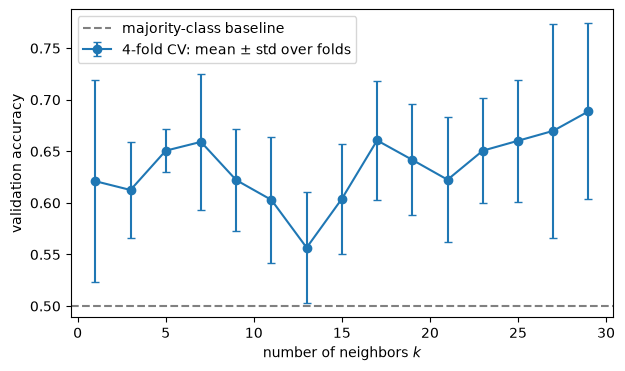

best k = 29   CV accuracy = 0.689


In [4]:
ks = np.arange(1, 30, 2)                 # odd k only: two classes can then never tie
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

scores = []                              # one row per fold, one column per k
for train_idx, val_idx in cv.split(X, y):
    fold_scores = []
    for k in ks:
        knn = KNeighborsClassifier(n_neighbors=k).fit(X[train_idx], y[train_idx])
        fold_scores.append(knn.score(X[val_idx], y[val_idx]))
    scores.append(fold_scores)
scores = np.array(scores)

mean, std = scores.mean(axis=0), scores.std(axis=0)
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(ks, mean, yerr=std, fmt='o-', capsize=3, label='4-fold CV: mean ± std over folds')
ax.axhline(0.5, color='gray', linestyle='--', label='majority-class baseline')
ax.set_xlabel("number of neighbors $k$"); ax.set_ylabel("validation accuracy"); ax.legend()
plt.show()

best_k = ks[np.argmax(mean)]
print(f"best k = {best_k}   CV accuracy = {mean.max():.3f}")

The error bars show the standard deviation of the accuracy over the 4 folds. They tell you how much
the score depends on *which* sequences end up in the validation fold, which is a first indication
of how much to trust differences between the points on the curve.

You will not write this loop by hand again: scikit-learn has it built in. `GridSearchCV` takes a
model, a grid of hyperparameter values and a CV splitter. It runs exactly your loop for every
value in the grid, keeps the value with the highest mean accuracy, and then refits a model with that
value on all the data it was given. Its attribute `best_params_` holds the chosen value and
`best_score_` the corresponding CV accuracy, which is your `mean.max()`.

Your result depends on one particular random split into folds (`random_state=RANDOM_STATE`), and a
different split is an equally valid experiment. The cell below checks `GridSearchCV` against your
answer, then repeats the search for 20 different random splits.

In [5]:
search = GridSearchCV(KNeighborsClassifier(), {'n_neighbors': ks}, cv=cv).fit(X, y)
assert search.best_params_['n_neighbors'] == best_k and np.isclose(search.best_score_, mean.max())
print("GridSearchCV agrees with your loop.")

winners = []
for seed in range(20):
    cv_seed = StratifiedKFold(n_splits=4, shuffle=True, random_state=seed)
    s = GridSearchCV(KNeighborsClassifier(), {'n_neighbors': ks}, cv=cv_seed).fit(X, y)
    winners.append(int(s.best_params_['n_neighbors']))
print("best k over 20 random splits:", winners)

GridSearchCV agrees with your loop.


best k over 20 random splits: [1, 3, 1, 5, 7, 3, 19, 19, 3, 1, 17, 29, 3, 5, 7, 29, 3, 1, 29, 1]


<div class="alert alert-info">

<b>Think about it.</b>

1. Given the error bars in your plot, is the best $k$ clearly better than the others? Why then
   does the selected $k$ change so much from one random split to the next?
2. What changes if you use more folds? What is the extreme case, and what does it cost?
3. `best_score_` is the highest of 15 noisy CV estimates, measured on the same folds that were
   used to pick the winner. Is it an honest estimate of how well the model will do on new
   sequences? Would it be more or less trustworthy with a grid of 200 values?
</div>

**Answer.** 1. No. The best value ($k = 29$, accuracy 0.69) has error bars of about ±0.08, which overlap almost every other $k$. Within the noise the curve is flat (0.56 to 0.69), though all of it is above the 0.5 baseline. So the winner is decided by which sequences happen to land in which fold, and it changes with the random split (anywhere from 1 to 29 here). For the same reason, it hardly matters which of these $k$ we use.

2. With more folds, each model trains on more of the data, and averaging over more folds makes the selection more stable. The cost is more model fits, and smaller validation folds. The extreme is leave-one-out ($K = n$): 106 fits per $k$, each validating on a single sequence, with no randomness left at all.

3. No. Each CV estimate is noisy, and `best_score_` reports the *maximum* of 15 of them, so it picks the $k$ that got lucky on these folds and then reports how lucky it got. The maximum of noisy numbers is systematically too high. With 200 values there are more chances to get lucky, so it is even more optimistic. Section 3 measures how big the effect is.

## 3. Nested cross-validation

Cross-validation answers the model selection question: which $k$? But the score of the winner is
not a reliable answer to the assessment question, because the same folds were used both to pick
the winner and to score it (question 3 above). To get an honest estimate, choosing the
hyperparameter has to count as **part of training**, and the result must be scored on data that
played no role in that choice.

The obvious fix is to set aside a test set first and do CV on the rest. On small data that brings
back the problem of section 2: one small test set gives one noisy number. **Nested
cross-validation** applies the CV idea to the test set as well, using two loops:

1. **Outer loop**: split the data into $K_{\text{out}}$ folds. Each outer fold in turn is put aside
   as the **test** set.
2. **Inner loop**: on the remaining data only, run the CV of section 2 to choose $k$.
3. Refit with that $k$ on all the outer training data, and score it once on the outer test fold.

In the figure below, the left side is the outer loop, and the box on the right zooms in on the
inner loop for the first outer fold. The test fold (dark) is never seen by the inner loop.

The mean outer test score estimates how well the whole *procedure* ("choose $k$ by CV, then fit")
does on new data. Different outer folds may choose different values of $k$. That is not a
problem, because we are evaluating the procedure, not one particular model.

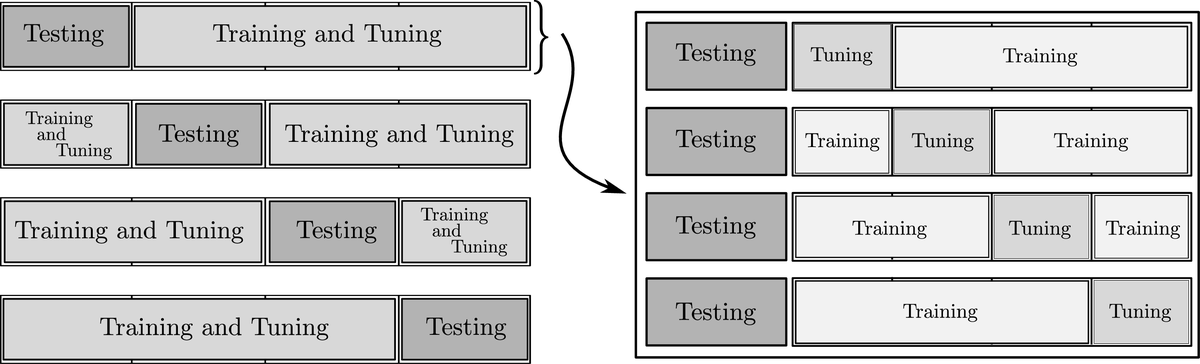

<div class="alert alert-success">

<b>EXERCISE 3.1</b>: <b>Implement nested CV for $k$-NN with 4 outer and 4 inner folds, as in the
figure.</b> For each outer fold, record the selected $k$, its mean inner CV accuracy and its outer
test accuracy. The inner loop is your code from Exercise 2.1, applied to the outer training part.
</div>

In [6]:
outer_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

chosen_k, inner_best, outer_test = [], [], []
for trval_idx, test_idx in outer_cv.split(X, y):
    X_trval, y_trval = X[trval_idx], y[trval_idx]     # used for choosing k AND for fitting
    X_test, y_test = X[test_idx], y[test_idx]         # touched once, at the very end

    inner_scores = []
    for train_idx, val_idx in inner_cv.split(X_trval, y_trval):
        fold_scores = []
        for k in ks:
            knn = KNeighborsClassifier(n_neighbors=k).fit(X_trval[train_idx], y_trval[train_idx])
            fold_scores.append(knn.score(X_trval[val_idx], y_trval[val_idx]))
        inner_scores.append(fold_scores)
    inner_mean = np.mean(inner_scores, axis=0)

    k_sel = ks[np.argmax(inner_mean)]
    final = KNeighborsClassifier(n_neighbors=k_sel).fit(X_trval, y_trval)

    chosen_k.append(k_sel)
    inner_best.append(inner_mean.max())
    outer_test.append(final.score(X_test, y_test))

print(pd.DataFrame({'selected k': chosen_k, 'inner CV acc.': inner_best, 'outer test acc.': outer_test}).round(3))
print(f"\nmean inner CV accuracy of the selected k: {np.mean(inner_best):.3f}")
print(f"nested CV accuracy:                       {np.mean(outer_test):.3f}")

   selected k  inner CV acc.  outer test acc.
0           1          0.646            0.630
1           5          0.647            0.667
2           3          0.738            0.538
3           1          0.688            0.538

mean inner CV accuracy of the selected k: 0.679
nested CV accuracy:                       0.593


In scikit-learn, nested CV is one line: a `GridSearchCV` is itself a model (its `fit` runs the
inner loop and refits), so `cross_val_score` can supply the outer loop.

In [7]:
knn_nested = cross_val_score(GridSearchCV(KNeighborsClassifier(), {'n_neighbors': ks}, cv=inner_cv), X, y, cv=outer_cv)
assert np.allclose(knn_nested, outer_test), "your nested CV differs from scikit-learn's - check it"
print("Identical to scikit-learn:", knn_nested.round(3))

Identical to scikit-learn: [0.63  0.667 0.538 0.538]


### Comparing two models

Nested CV is also the fair way to compare *methods*. Each method tunes its own hyperparameters in
the inner loop, and all of them are tested on the same outer folds. Comparing the `best_score_`
of two separate grid searches would instead compare two optimistic numbers, which may be
optimistic by different amounts.

We compare $k$-NN with linear discriminant analysis (LDA, lab 4). LDA needs an estimate of the
$108 \times 108$ covariance matrix $\hat\Sigma$ of the features, from only about 80 training
sequences. That cannot be done reliably. In fact $\hat\Sigma$ is singular here, because the four
dummy columns of each position always sum to 1. **Shrinkage** fixes this by blending the estimate
with a simple diagonal matrix,

$$ \hat\Sigma_{\text{shrunk}} = (1-\alpha)\,\hat\Sigma + \alpha\,\nu I , $$

with $\nu$ the average feature variance. At $\alpha = 0$ this is ordinary LDA. At $\alpha = 1$ the
correlations between features are ignored completely, and each sequence is assigned to the class
whose mean is closest. The weight $\alpha \in [0, 1]$ is a hyperparameter, just like $k$, so it is
tuned in the inner loop.

<div class="alert alert-success">

<b>EXERCISE 3.2</b>: <b>Estimate the accuracy of
<code>LinearDiscriminantAnalysis(solver='lsqr')</code> with nested CV, tuning
<code>shrinkage</code> over <code>np.linspace(0, 1, 11)</code>, with the same inner and outer
folds.</b>
</div>

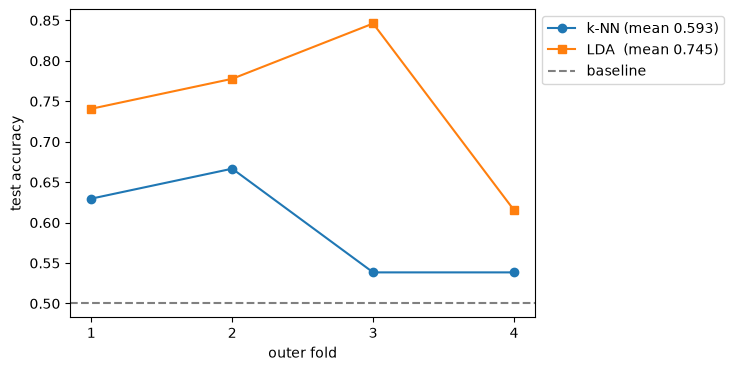

In [8]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_search = GridSearchCV(LinearDiscriminantAnalysis(solver='lsqr'), {'shrinkage': np.linspace(0, 1, 11)}, cv=inner_cv)
lda_nested = cross_val_score(lda_search, X, y, cv=outer_cv)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([1, 2, 3, 4], knn_nested, 'o-', label=f"k-NN (mean {knn_nested.mean():.3f})")
ax.plot([1, 2, 3, 4], lda_nested, 's-', label=f"LDA  (mean {lda_nested.mean():.3f})")
ax.axhline(0.5, color='gray', linestyle='--', label='baseline')
ax.set_xticks([1, 2, 3, 4]); ax.set_xlabel("outer fold"); ax.set_ylabel("test accuracy")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

### The final model

Nested CV evaluated a procedure, and built one model per outer fold along the way. None of those is
the model you would deploy: each one was trained on only three quarters of the data. To get the
final model, run the same procedure once more on **all** the data.

With it, report the nested CV accuracy as an estimate of how well this *procedure* performs on new
data. Because the final model is trained on a bit more data, it will typically do slightly better,
but at this sample size that difference is small compared to the noise in the estimate. The
spread over the outer folds shows how noisy the estimate is. It is not a formal confidence
interval, because the folds share most of their training data.

In [9]:
final_model = lda_search.fit(X, y)
print(f"selected shrinkage: {final_model.best_params_['shrinkage']:.1f}")
print(f"report:       nested CV accuracy {lda_nested.mean():.3f} (outer folds: {', '.join(f'{s:.2f}' for s in lda_nested)})")
print(f"don't report: best_score_ {final_model.best_score_:.3f}")

selected shrinkage: 1.0
report:       nested CV accuracy 0.745 (outer folds: 0.74, 0.78, 0.85, 0.62)
don't report: best_score_ 0.793


<div class="alert alert-info">

<b>Think about it.</b>

1. In Exercise 3.1, compare the inner CV accuracy with the outer test accuracy. Which is higher,
   and how does that relate to question 3 of section 2?
2. The outer folds did not all select the same $k$. So what exactly did nested CV evaluate?
3. Which method would you choose, and how sure are you? Why is it fair to compare the two
   fold by fold?
</div>

**Answer.** 1. The inner score is higher in 3 of the 4 folds: 0.68 against 0.59 on average. That is the optimism from section 2, question 3. The inner score was used to choose $k$, while the outer test fold is used only once, after the choice. Only the outer score is free of the selection.

2. Not one model, but the *procedure*: "choose $k$ by 4-fold CV, then refit". Our final model is made by exactly that procedure on all the data, which is why the nested score is the one to report with it.

3. LDA. It wins in every outer fold, with a mean of 0.75 against 0.59. Comparing fold by fold is fair because both methods were tested on exactly the same sequences in each fold, so neither got an easier test set. Stay modest, though: this is 4 folds on 106 sequences, and LDA alone ranges from 0.62 to 0.85. Interestingly, the selected shrinkage is 1.0, which turns LDA into "assign to the class with the nearest mean": with this little data, the simplest model wins.

<div class="alert alert-warning">

<b>Take-home messages</b>

- Choose hyperparameters by cross-validation on training data, never on the test set.
- On small data, CV scores are noisy: check the spread before trusting a winner.
- `best_score_` is optimistic, because it is the best of many noisy estimates. Nested CV gives an honest
  estimate of the whole procedure, and is the fair way to compare methods.
- The final model is the procedure (`GridSearchCV`) refitted on all the data. Report the nested
  CV score alongside it, as an estimate of how well that procedure performs.
</div>